# 01 Run Experiments

Run CLIP zero-shot baseline + ablations on Caltech101.
This notebook is configured for smoke runs by default and persists all intermediate artifacts for visualization.


## Cell 1 - Imports and context loading


In [1]:
import json
import math
import sys
import time
from pathlib import Path

import clip
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if (PROJECT_ROOT / "ha2.md").exists() is False:
    # fallback for Windows kernel starting at repo root already
    PROJECT_ROOT = Path(str(PROJECT_ROOT))

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from ha2_common import set_seed
from ha2_experiments import (
    build_text_features_per_template,
    encode_images,
    evaluate_predictions,
    format_prompt,
    load_caltech_dataset,
    load_npz,
    model_slug,
    predict_feature_mean,
    predict_feature_mean_with_options,
    predict_logit_mean,
    resolve_caltech_root,
    save_npz,
    template_subsets,
)

sns.set_theme(style="whitegrid")
print("Project root:", PROJECT_ROOT)


Project root: D:\code\HA2


## Cell 2 - Load setup artifacts and runtime switches


In [2]:
artifacts_root = PROJECT_ROOT / "artifacts"
config = json.loads((artifacts_root / "config_resolved.json").read_text(encoding="utf-8"))

class_names = json.loads((artifacts_root / "meta" / "class_names.json").read_text(encoding="utf-8"))
templates_simple = json.loads((artifacts_root / "meta" / "templates_simple.json").read_text(encoding="utf-8"))
templates_full = json.loads((artifacts_root / "meta" / "templates_full.json").read_text(encoding="utf-8"))

eval_indices_full = pd.read_csv(artifacts_root / "meta" / "eval_indices.csv")["index"].to_numpy(dtype=np.int64)
smoke_indices = pd.read_csv(artifacts_root / "meta" / "smoke_indices.csv")["index"].to_numpy(dtype=np.int64)

RUN_MODE = "full"  # smoke | full
ACTIVE_INDICES = smoke_indices if RUN_MODE == "smoke" else eval_indices_full

USE_CACHED_EMBEDS = True
RECOMPUTE_EMBEDS = False
SAVE_LOGITS = False

device = "cuda" if torch.cuda.is_available() else "cpu"
use_amp = device == "cuda"

seed_main = int(config["seed_main"])
set_seed(seed_main)

models = config["models"]
batch_hint = config["batch_hint"]
num_workers = int(config["num_workers"])

print("RUN_MODE:", RUN_MODE, "samples:", len(ACTIVE_INDICES))
print("Device:", device)
print("Models:", models)


RUN_MODE: full samples: 8677
Device: cuda
Models: ['ViT-B/32', 'ViT-B/16']


## Cell 3 - Prepare results/cache directories and experiment registry


In [3]:
cache_root = artifacts_root / "cache"
results_root = artifacts_root / "results"
figures_root = artifacts_root / "figures"
runtime_root = artifacts_root / "runtime"

for p in [cache_root, results_root, figures_root, runtime_root]:
    p.mkdir(parents=True, exist_ok=True)

k_list = [1, 2, 4, 8, 16, 34]
k_seeds = [3407, 3408, 3409, 3410, 3411]

exp_registry = pd.DataFrame(
    [
        {"group": "baseline", "exp": "B0_chance", "note": "uniform random over classes"},
        {"group": "baseline", "exp": "B1_simple", "note": "single template"},
        {"group": "main", "exp": "M1_ensemble_all", "note": "all 34 templates, feature mean"},
        {"group": "ablation", "exp": "A1_template_count", "note": "k templates with 5 seeds"},
        {"group": "ablation", "exp": "A2_aggregation", "note": "feature-mean vs logit-mean"},
        {"group": "ablation", "exp": "A3_normalization", "note": "with vs without l2 norm"},
        {"group": "ablation", "exp": "A4_backbone", "note": "ViT-B/32 vs ViT-B/16"},
    ]
)
display(exp_registry)


,group,exp,note
0,baseline,B0_chance,uniform random over classes
1,baseline,B1_simple,single template
2,main,M1_ensemble_all,"all 34 templates, feature mean"
3,ablation,A1_template_count,k templates with 5 seeds
4,ablation,A2_aggregation,feature-mean vs logit-mean
5,ablation,A3_normalization,with vs without l2 norm
6,ablation,A4_backbone,ViT-B/32 vs ViT-B/16


## Cell 4 - Load dataset and verify index alignment


In [4]:
data_root = Path(config["data_root"])
caltech_root = resolve_caltech_root(data_root)
dataset_for_raw = load_caltech_dataset(caltech_root, transform=None)

labels_all = np.array(dataset_for_raw.y, dtype=np.int64)
labels_active = labels_all[ACTIVE_INDICES]

print("Caltech root:", caltech_root)
print("Dataset size:", len(dataset_for_raw), "| Active size:", len(ACTIVE_INDICES))
print("Label range:", labels_active.min(), labels_active.max(), "n_classes:", len(class_names))


Caltech root: D:\code\HA2\data\caltech_fallback
Dataset size: 8677 | Active size: 8677
Label range: 0 100 n_classes: 101


## Cell 5 - Encode or load image embeddings per model


In [5]:
image_cache = {}
runtime_rows = []

for model_name in models:
    slug = model_slug(model_name)
    model_cache_dir = cache_root / slug
    model_cache_dir.mkdir(parents=True, exist_ok=True)
    cache_path = model_cache_dir / f"image_embeds_raw_{RUN_MODE}.npz"

    if USE_CACHED_EMBEDS and cache_path.exists() and not RECOMPUTE_EMBEDS:
        pack = load_npz(cache_path)
        image_cache[model_name] = {
            "image_feats": pack["image_feats"],
            "labels": pack["labels"],
            "indices": pack["indices"],
        }
        runtime_rows.append(
            {
                "stage": "load_cache",
                "model": model_name,
                "elapsed_sec": float(pack.get("elapsed_sec", np.array([np.nan]))[0]),
                "peak_mem_gb": float(pack.get("peak_mem_gb", np.array([np.nan]))[0]),
                "num_samples": int(pack["labels"].shape[0]),
            }
        )
        print(f"Loaded cached image features for {model_name}: {cache_path}")
        continue

    print(f"Encoding images for {model_name} ...")
    model, preprocess = clip.load(model_name, device=device, jit=False)
    dataset_pre = load_caltech_dataset(caltech_root, transform=preprocess)
    batch_size = int(batch_hint[model_name])

    feats, labels, inds, rt = encode_images(
        dataset=dataset_pre,
        indices=ACTIVE_INDICES,
        model=model,
        device=device,
        batch_size=batch_size,
        num_workers=num_workers,
        normalize=False,
        use_amp=use_amp,
    )

    save_npz(
        cache_path,
        image_feats=feats,
        labels=labels,
        indices=inds,
        elapsed_sec=np.array([rt["elapsed_sec"]], dtype=np.float32),
        peak_mem_gb=np.array([rt["peak_mem_gb"]], dtype=np.float32),
    )
    image_cache[model_name] = {"image_feats": feats, "labels": labels, "indices": inds}
    runtime_rows.append(
        {
            "stage": "encode_images",
            "model": model_name,
            "elapsed_sec": rt["elapsed_sec"],
            "peak_mem_gb": rt["peak_mem_gb"],
            "num_samples": rt["num_samples"],
        }
    )

    del model
    if device == "cuda":
        torch.cuda.empty_cache()

runtime_df = pd.DataFrame(runtime_rows)
display(runtime_df)


Encoding images for ViT-B/32 ...


Encoding images for ViT-B/16 ...


,stage,model,elapsed_sec,peak_mem_gb,num_samples
0,encode_images,ViT-B/32,27.152207,0.599550,8677
1,encode_images,ViT-B/16,27.293047,0.686335,8677


## Cell 6 - B0 random chance baseline


In [6]:
rng = np.random.default_rng(seed_main)
pred_b0 = rng.integers(low=0, high=len(class_names), size=len(ACTIVE_INDICES), dtype=np.int64)
labels_ref = labels_active
b0_metrics = evaluate_predictions(pred_b0, labels_ref)
print("B0 chance accuracy:", round(b0_metrics["accuracy"], 4), "samples:", b0_metrics["num_samples"])


B0 chance accuracy: 0.0104 samples: 8677


## Cell 7 - B1 simple and M1 ensemble-all


In [7]:
pred_rows = []
metric_rows = []

for model_name in models:
    model, _ = clip.load(model_name, device=device, jit=False)
    image_feats = image_cache[model_name]["image_feats"]
    labels = image_cache[model_name]["labels"]
    indices = image_cache[model_name]["indices"]

    # B1 simple
    text_simple = build_text_features_per_template(
        model=model,
        class_names=class_names,
        templates=templates_simple,
        device=device,
        normalize=True,
    )
    logits_s, pred_s, conf_s = predict_feature_mean(image_feats, text_simple)
    m_s = evaluate_predictions(pred_s, labels)
    metric_rows.append(
        {
            "run_mode": RUN_MODE,
            "model": model_name,
            "exp": "B1_simple",
            "acc": m_s["accuracy"],
            "num_samples": m_s["num_samples"],
            "n_templates": 1,
            "agg": "feature_mean",
            "normalize": True,
            "seed": seed_main,
        }
    )

    # M1 ensemble all
    text_full = build_text_features_per_template(
        model=model,
        class_names=class_names,
        templates=templates_full,
        device=device,
        normalize=True,
    )
    logits_e, pred_e, conf_e = predict_feature_mean(image_feats, text_full)
    m_e = evaluate_predictions(pred_e, labels)
    metric_rows.append(
        {
            "run_mode": RUN_MODE,
            "model": model_name,
            "exp": "M1_ensemble_all",
            "acc": m_e["accuracy"],
            "num_samples": m_e["num_samples"],
            "n_templates": len(templates_full),
            "agg": "feature_mean",
            "normalize": True,
            "seed": seed_main,
        }
    )

    # predictions for downstream viz/statistics
    for i in range(len(indices)):
        pred_rows.append(
            {
                "run_mode": RUN_MODE,
                "model": model_name,
                "sample_index": int(indices[i]),
                "label_id": int(labels[i]),
                "exp": "B1_simple",
                "pred_id": int(pred_s[i]),
                "conf": float(conf_s[i]),
            }
        )
        pred_rows.append(
            {
                "run_mode": RUN_MODE,
                "model": model_name,
                "sample_index": int(indices[i]),
                "label_id": int(labels[i]),
                "exp": "M1_ensemble_all",
                "pred_id": int(pred_e[i]),
                "conf": float(conf_e[i]),
            }
        )

    if SAVE_LOGITS:
        save_npz(results_root / f"logits_simple_{model_slug(model_name)}_{RUN_MODE}.npz", logits=logits_s)
        save_npz(results_root / f"logits_ensall_{model_slug(model_name)}_{RUN_MODE}.npz", logits=logits_e)

    del model
    if device == "cuda":
        torch.cuda.empty_cache()

metrics_df = pd.DataFrame(metric_rows)
preds_df = pd.DataFrame(pred_rows)
display(metrics_df)
print("Pred rows:", len(preds_df))


,run_mode,model,exp,acc,num_samples,n_templates,agg,normalize,seed
0,full,ViT-B/32,B1_simple,0.875879,8677,1,feature_mean,True,3407
1,full,ViT-B/32,M1_ensemble_all,0.872882,8677,34,feature_mean,True,3407
2,full,ViT-B/16,B1_simple,0.883370,8677,1,feature_mean,True,3407
3,full,ViT-B/16,M1_ensemble_all,0.887058,8677,34,feature_mean,True,3407


Pred rows: 34708


## Cell 8 - A1 template-count ablation


In [8]:
a1_rows = []
force_tpl = templates_simple[0].replace("{CLASS}", "{}")

for model_name in models:
    model, _ = clip.load(model_name, device=device, jit=False)
    image_feats = image_cache[model_name]["image_feats"]
    labels = image_cache[model_name]["labels"]

    for k in k_list:
        subsets = template_subsets(
            templates=templates_full,
            k=k,
            seeds=k_seeds,
            force_include=[force_tpl] if k >= 1 else None,
        )
        for seed_k, tpl_subset in subsets:
            text_k = build_text_features_per_template(
                model=model,
                class_names=class_names,
                templates=tpl_subset,
                device=device,
                normalize=True,
            )
            _, pred_k, _ = predict_feature_mean(image_feats, text_k)
            m_k = evaluate_predictions(pred_k, labels)
            a1_rows.append(
                {
                    "run_mode": RUN_MODE,
                    "model": model_name,
                    "exp": "A1_template_count",
                    "k": int(k),
                    "seed": int(seed_k),
                    "acc": m_k["accuracy"],
                }
            )

    del model
    if device == "cuda":
        torch.cuda.empty_cache()

a1_df = pd.DataFrame(a1_rows)
a1_summary = a1_df.groupby(["run_mode", "model", "k"], as_index=False).agg(acc_mean=("acc", "mean"), acc_std=("acc", "std"))
display(a1_summary.head(12))


,run_mode,model,k,acc_mean,acc_std
0,full,ViT-B/16,1,0.883370,0.000000
1,full,ViT-B/16,2,0.888487,0.005299
2,full,ViT-B/16,4,0.887634,0.003988
3,full,ViT-B/16,8,0.888994,0.001834
4,full,ViT-B/16,16,0.888879,0.003142
5,full,ViT-B/16,34,0.887058,0.000000
6,full,ViT-B/32,1,0.875879,0.000000
7,full,ViT-B/32,2,0.874542,0.004474
8,full,ViT-B/32,4,0.872030,0.005400
9,full,ViT-B/32,8,0.872006,0.007249


## Cell 9 - A2 aggregation and A3 normalization ablations


In [9]:
a23_rows = []

for model_name in models:
    model, _ = clip.load(model_name, device=device, jit=False)
    image_feats = image_cache[model_name]["image_feats"]
    labels = image_cache[model_name]["labels"]

    # A2: feature_mean vs logit_mean with normalization on
    text_norm = build_text_features_per_template(
        model=model,
        class_names=class_names,
        templates=templates_full,
        device=device,
        normalize=True,
    )
    _, pred_fm, _ = predict_feature_mean(image_feats, text_norm)
    _, pred_lm, _ = predict_logit_mean(image_feats, text_norm)
    a23_rows.append(
        {
            "run_mode": RUN_MODE,
            "model": model_name,
            "exp": "A2_aggregation",
            "variant": "feature_mean",
            "acc": evaluate_predictions(pred_fm, labels)["accuracy"],
        }
    )
    a23_rows.append(
        {
            "run_mode": RUN_MODE,
            "model": model_name,
            "exp": "A2_aggregation",
            "variant": "logit_mean",
            "acc": evaluate_predictions(pred_lm, labels)["accuracy"],
        }
    )

    # A3: normalize on/off (feature-mean)
    _, pred_norm_on, _ = predict_feature_mean_with_options(
        image_feats,
        text_norm,
        normalize_image=True,
        normalize_text=True,
    )
    a23_rows.append(
        {
            "run_mode": RUN_MODE,
            "model": model_name,
            "exp": "A3_normalization",
            "variant": "norm_on",
            "acc": evaluate_predictions(pred_norm_on, labels)["accuracy"],
        }
    )

    text_nonorm = build_text_features_per_template(
        model=model,
        class_names=class_names,
        templates=templates_full,
        device=device,
        normalize=False,
    )
    _, pred_nonorm, _ = predict_feature_mean_with_options(
        image_feats,
        text_nonorm,
        normalize_image=False,
        normalize_text=False,
    )
    a23_rows.append(
        {
            "run_mode": RUN_MODE,
            "model": model_name,
            "exp": "A3_normalization",
            "variant": "norm_off",
            "acc": evaluate_predictions(pred_nonorm, labels)["accuracy"],
        }
    )

    del model
    if device == "cuda":
        torch.cuda.empty_cache()

a23_df = pd.DataFrame(a23_rows)
display(a23_df)


,run_mode,model,exp,variant,acc
0,full,ViT-B/32,A2_aggregation,feature_mean,0.872882
1,full,ViT-B/32,A2_aggregation,logit_mean,0.866774
2,full,ViT-B/32,A3_normalization,norm_on,0.872882
3,full,ViT-B/32,A3_normalization,norm_off,0.859629
4,full,ViT-B/16,A2_aggregation,feature_mean,0.887058
5,full,ViT-B/16,A2_aggregation,logit_mean,0.890630
6,full,ViT-B/16,A3_normalization,norm_on,0.887058
7,full,ViT-B/16,A3_normalization,norm_off,0.858707


## Cell 10 - Consolidate metrics/predictions and sanity checks


In [10]:
b0_rows = []
for model_name in models:
    b0_rows.append(
        {
            "run_mode": RUN_MODE,
            "model": model_name,
            "exp": "B0_chance",
            "acc": b0_metrics["accuracy"],
            "num_samples": b0_metrics["num_samples"],
            "n_templates": 0,
            "agg": "none",
            "normalize": False,
            "seed": seed_main,
        }
    )

metrics_df = pd.concat([pd.DataFrame(b0_rows), metrics_df], ignore_index=True)
metrics_all = pd.concat([metrics_df, a23_df], ignore_index=True, sort=False)

# add A1 summary rows
a1_summary_rows = (
    a1_df.groupby(["run_mode", "model", "k"], as_index=False)
    .agg(acc=("acc", "mean"), acc_std=("acc", "std"))
    .rename(columns={"k": "n_templates"})
)
a1_summary_rows["exp"] = "A1_template_count"
a1_summary_rows["agg"] = "feature_mean"
a1_summary_rows["normalize"] = True
metrics_all = pd.concat([metrics_all, a1_summary_rows], ignore_index=True, sort=False)

# sanity checks
simple_rows = preds_df[preds_df["exp"] == "B1_simple"].sort_values(["model", "sample_index"])
ens_rows = preds_df[preds_df["exp"] == "M1_ensemble_all"].sort_values(["model", "sample_index"])
checks = {
    "pred_count_match": len(simple_rows) == len(ens_rows) == len(models) * len(ACTIVE_INDICES),
    "pred_id_range": int(preds_df["pred_id"].min()) >= 0 and int(preds_df["pred_id"].max()) < len(class_names),
    "label_id_range": int(preds_df["label_id"].min()) >= 0 and int(preds_df["label_id"].max()) < len(class_names),
    "k34_present": bool(((a1_summary_rows["n_templates"] == 34).any())),
}

# k=1 approximate equivalence sanity
a1_k1 = a1_df[a1_df["k"] == 1].groupby(["run_mode", "model"], as_index=False)["acc"].mean().rename(columns={"acc": "acc_k1_mean"})
b1_acc = metrics_df[metrics_df["exp"] == "B1_simple"][["run_mode", "model", "acc"]].rename(columns={"acc": "acc_b1"})
k1_cmp = a1_k1.merge(b1_acc, on=["run_mode", "model"], how="inner")
k1_cmp["abs_diff"] = (k1_cmp["acc_k1_mean"] - k1_cmp["acc_b1"]).abs()
checks["k1_close_to_b1"] = bool((k1_cmp["abs_diff"] <= 0.05).all())

check_df = pd.DataFrame({"check": list(checks.keys()), "pass": list(checks.values())})
display(check_df)
display(k1_cmp)


,check,pass
0,pred_count_match,True
1,pred_id_range,True
2,label_id_range,True
3,k34_present,True
4,k1_close_to_b1,True


,run_mode,model,acc_k1_mean,acc_b1,abs_diff
0,full,ViT-B/16,0.883370,0.883370,1.110223e-16
1,full,ViT-B/32,0.875879,0.875879,1.110223e-16


## Cell 11 - Save outputs for 02 analysis notebook


In [11]:
metrics_path = results_root / f"metrics_{RUN_MODE}.csv"
preds_path = results_root / f"predictions_{RUN_MODE}.parquet"
a1_path = results_root / f"a1_template_count_{RUN_MODE}.csv"
runtime_path = runtime_root / f"runtime_{RUN_MODE}.csv"
sanity_path = results_root / f"sanity_{RUN_MODE}.json"

metrics_all.to_csv(metrics_path, index=False)
preds_df.to_parquet(preds_path, index=False)
a1_df.to_csv(a1_path, index=False)
runtime_df.to_csv(runtime_path, index=False)

sanity_payload = {
    "checks": checks,
    "k1_compare": k1_cmp.to_dict(orient="records"),
    "run_mode": RUN_MODE,
    "n_samples": int(len(ACTIVE_INDICES)),
}
(sanity_path).write_text(json.dumps(sanity_payload, indent=2), encoding="utf-8")

print("Saved:", metrics_path)
print("Saved:", preds_path)
print("Saved:", a1_path)
print("Saved:", runtime_path)
print("Saved:", sanity_path)


Saved: D:\code\HA2\artifacts\results\metrics_full.csv
Saved: D:\code\HA2\artifacts\results\predictions_full.parquet
Saved: D:\code\HA2\artifacts\results\a1_template_count_full.csv
Saved: D:\code\HA2\artifacts\runtime\runtime_full.csv
Saved: D:\code\HA2\artifacts\results\sanity_full.json


## Cell 12 - Quick diagnostic figure (runtime and key accuracy)


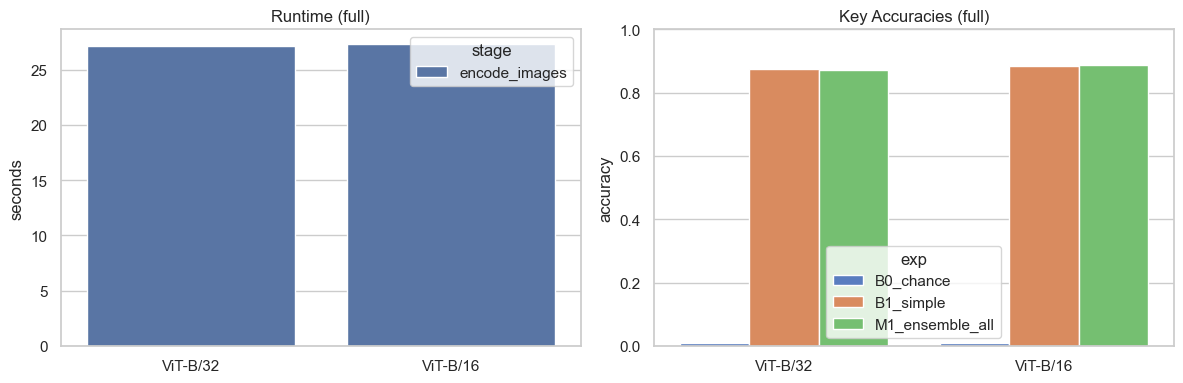

Saved: D:\code\HA2\artifacts\figures\fig_runtime_and_keyacc_full.png


In [12]:
# Runtime chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

rt_plot = runtime_df[runtime_df["stage"].isin(["encode_images", "load_cache"])].copy()
sns.barplot(data=rt_plot, x="model", y="elapsed_sec", hue="stage", ax=axes[0], palette="deep")
axes[0].set_title(f"Runtime ({RUN_MODE})")
axes[0].set_ylabel("seconds")
axes[0].set_xlabel("")

key = metrics_df[metrics_df["exp"].isin(["B0_chance", "B1_simple", "M1_ensemble_all"])].copy()
sns.barplot(data=key, x="model", y="acc", hue="exp", ax=axes[1], palette="muted")
axes[1].set_title(f"Key Accuracies ({RUN_MODE})")
axes[1].set_ylabel("accuracy")
axes[1].set_xlabel("")
axes[1].set_ylim(0, 1)

plt.tight_layout()
fig_path = figures_root / f"fig_runtime_and_keyacc_{RUN_MODE}.png"
plt.savefig(fig_path, dpi=160)
plt.show()
print("Saved:", fig_path)
